In [36]:
import sys
import os
import glob
import aubio
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from scipy import ndimage

lib_path = '../../vrProjector/'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)
    
import vrProjector

In [10]:
path0 = sorted(glob.glob(data_path + rec_name + "/img*.jpg"))[0] # Make sure ref image is first
len(sorted(glob.glob(data_path + rec_name + "/img*.jpg")))

787

### Combine all image diffs

In [107]:
paths = sorted(glob.glob(data_path + rec_name + "/img*.jpg"))
im_mask = np.array(Image.open(data_path + rec_name + "/mask.jpg"))[:,:,1].clip(max=1)
for i, file in enumerate(paths):
    im = np.array(Image.open(file)).astype(np.int16)[:,:,1]
    if i == 0:
        max_diffs = np.zeros(im.shape)
        im0 = im
    max_diffs = np.maximum(max_diffs, np.sqrt((im.astype("float") - im0.astype("float")) ** 2)*im_mask)
max_diffs.shape

(960, 1920)

In [11]:
data_path = "../data/"
rec_name="rec_2"
paths = [path0] + sorted(glob.glob(data_path + rec_name + "/img*.jpg"))[:1]
im_mask = np.array(Image.open(data_path + rec_name + "/mask.jpg"))[:,:,1].clip(max=1)
print(im_mask.shape)
data = None
for i, file in enumerate(paths):
    im = np.array(Image.open(file)).astype(np.int16)[:,:,1]
    if data is None:
        data = np.zeros([len(paths) - 1, im.shape[0], im.shape[1]])
        im0 = im
    data[i-1,:,:] = np.sqrt((im.astype("float") - im0.astype("float")) ** 2)*im_mask
    #print(i, np.min(data[i-1]), np.max(data[i-1]))
data.shape

(960, 1920)


(1, 960, 1920)

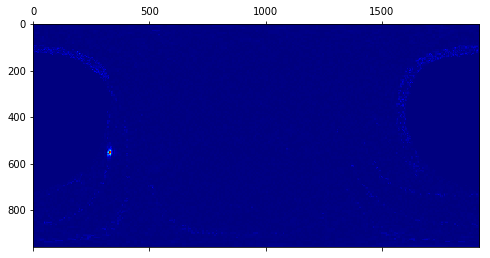

In [45]:
plt.matshow(data[10], cmap='jet')

### Get Image COs

In [348]:
n=179
int((n-n%60)/60)

2

In [350]:
pixel_cos = []
pix_imgs = data
kernel = np.ones((40, 40))
len(pix_imgs)
d = 0
for idx, img in enumerate(pix_imgs):
    conv = ndimage.convolve(img, kernel, mode='constant')
    pix = np.array(np.unravel_index(np.argmax(conv), conv.shape))
    
    if len(pixel_cos) > 1:
        d = np.linalg.norm(pix - pixel_cos[-1])
    
    pixel_cos.append(pix)
    print("Pixel Nr:", idx, ". Co:", pixel_cos[-1], d)

TypeError: object of type 'NoneType' has no len()

In [47]:
all_cos += pixel_cos
len(all_cos)

786

In [55]:
list(all_cos[0])

[401, 1460]

In [57]:
with open('/home/gabriel/git/rizhom/data/rec_2_img_cos_2.json', 'w') as outfile:
    json.dump([co.tolist() for co in all_cos], outfile)

In [6]:
import json
with open('/home/gabriel/git/rizhom/data/rec_2_img_cos.json') as json_file:  
    all_cos = json.load(json_file)
all_cos = [np.array(co) for co in all_cos]

In [84]:
8*60

480

In [331]:
co_p = np.array([0,0])
red_cos = []
allcos_idxs = []
for idx, co in enumerate(all_cos[2:]):
    if idx in [100, 45, 551, 362, 212, 369, 372, 375, 378, 380, 600, 97, 95, 276, 195, 204, 201]:
        continue
       
    if co[1] > 1640 and co[0] > 100 and co[0] < 300: # Mask 1
        continue
    
    if co[1] > 200 and co[1] < 300 and co[0] > 170 and co[0] < 220: # Mask 2
        continue
    
    d = np.linalg.norm(co - co_p)

    
    if d > 14.4:
        red_cos.append(co)
        co_p = co
        allcos_idxs.append(idx)
        

len(red_cos)

480

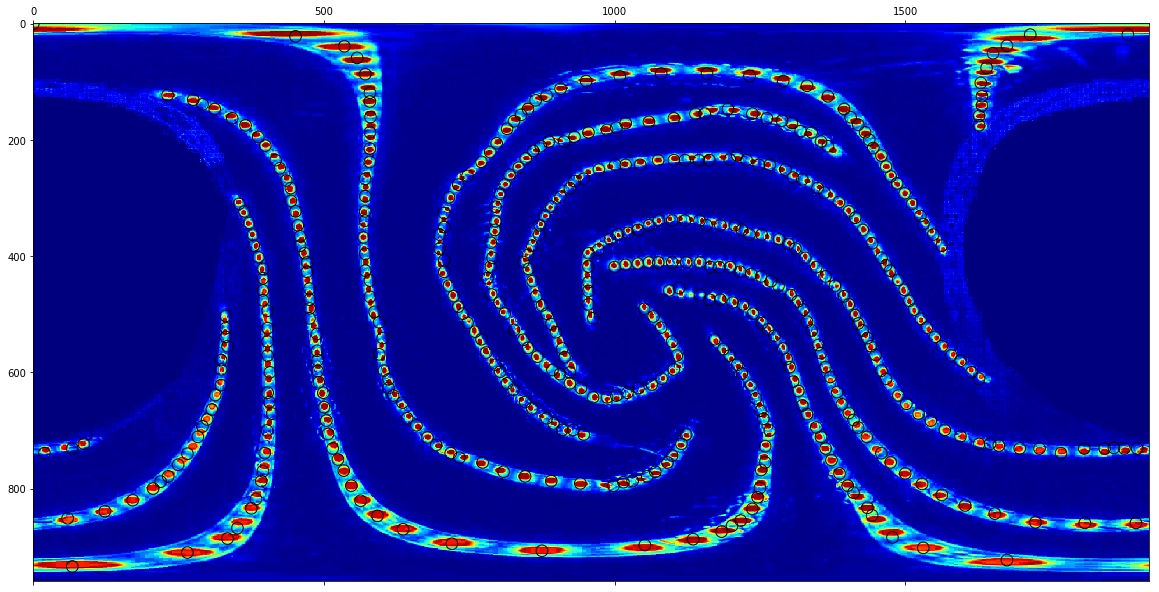

In [358]:
plt.figure(figsize=(20,10))
plt.matshow(max_diffs, cmap='jet', fignum=1)

ax = plt.gca()
for idx, co in enumerate(red_cos):
    
    ax.add_artist(plt.Circle(co[::-1], 10, fill=False))
    # ax.add_artist(plt.text(co[::-1][0], co[::-1][1], str(allcos_idxs[idx]), fontsize=12))

In [61]:
# Flip cos
red_cos = [np.array([co[1], co[0]]) for co in red_cos]

In [333]:
photo_width_deg = 2*np.pi
photo_height_deg = np.pi
photo_width_px = 1920
photo_height_px = 960
polar_cos = []
for co in red_cos:
    phi = photo_width_deg * (co[1] - photo_width_px/2) / photo_width_px
    theta = photo_height_deg * (photo_height_px - co[0]) / photo_height_px
    
    print([phi, theta], co)
    polar_cos.append([phi, theta])

[1.682061066609535, 1.750783405906812] [ 425 1474]
[1.7278759594743862, 1.698423528346982] [ 441 1488]
[1.7638733752967692, 1.6427911584396628] [ 458 1499]
[1.790053314076684, 1.5806138038373647] [ 477 1507]
[1.8162332528565992, 1.5315264186250241] [ 492 1515]
[1.8555031610264716, 1.4791665410651942] [ 508 1527]
[1.8882280845013653, 1.4300791558528538] [ 523 1537]
[1.9340429773662164, 1.3777192782930239] [ 539 1551]
[1.9733128855360889, 1.325359400733194] [ 555 1563]
[2.0256727630959186, 1.2729995231733642] [ 571 1579]
[2.0780326406557483, 1.24354709204596] [ 580 1595]
[2.1402099952580467, 1.1780972450961724] [ 600 1614]
[2.1827523957754082, 1.1420998292737894] [ 611 1627]
[-3.1415926535897927, 3.1415926535897927] [0 0]
[0.533416252640767, 0.8279405639148101] [ 707 1123]
[0.507236313860852, 0.7755806863549801] [ 723 1115]
[0.45487643630102215, 0.7101308394051927] [ 743 1099]
[0.4286964975211072, 0.6708609312353204] [ 755 1091]
[0.3599741582238305, 0.6185010536754906] [ 771 1070]
[0.314

In [334]:
len(polar_cos)

480

In [357]:
pixels_polar = []
for idx, co in enumerate(polar_cos):
    pix_idx = (idx - 308) % 480 # Initial pixel offset
    pix_idx = pix_idx + int((pix_idx-pix_idx%60)/60)*4 # shift for 64 instead of 60 per line
    pixels_polar.append({"idx" : str(pix_idx).zfill(3), "theta" : co[1], "phi" : co[0]})

with open('../data/rec_2_polar.json', 'w') as fp:
    json.dump(pixels_polar, fp, sort_keys=True, indent=4 * ' ')

In [ ]:
img_w_px = 1920;
img_h_px = 960;

double img_ha_deg = 0;
double img_va_deg = 0;
# Camera rotation angles
double hcam_deg = 230;
double vcam_deg = 60;
# Camera rotation angles in radians
double hcam_rad = hcam_deg/180.0*PI;
double vcam_rad = vcam_rad/180.0*PI;
# Rotation around y-axis for vertical rotation of camera
Matrix rot_y = {
    cos(vcam_rad), 0, sin(vcam_rad),
    0, 1, 0,
    -sin(vcam_rad), 0, cos(vcam_rad)
};
# Rotation around z-axis for horizontal rotation of camera
Matrix rot_z = {
    cos(hcam_rad), -sin(hcam_rad), 0,
    sin(hcam_rad), cos(hcam_rad), 0,
    0, 0, 1
};

for co in red_cos:
    # Calculate relative position to center in degrees
    double p_theta = (j - img_w_px / 2.0) / img_w_px * img_w_deg / 180.0 * np.pi;
    double p_phi = -(i - img_h_px / 2.0) / img_h_px * img_h_deg / 180.0 * np.pi;

    # Transform into cartesian coordinates
    double p_x = cos(p_phi) * cos(p_theta);
    double p_y = cos(p_phi) * sin(p_theta);
    double p_z = sin(p_phi);
    Vector p0 = {p_x, p_y, p_z};

    # Apply rotation matrices (note, z-axis is the vertical one)
    # First vertically
    Vector p1 = rot_y * p0;
    Vector p2 = rot_z * p1;

    # Transform back into spherical coordinates
    double theta = atan2(p2[1], p2[0]);
    double phi = asin(p2[2]);

    # Retrieve longitude,latitude
    double longitude = theta / PI * 180.0;
    double latitude = phi / PI * 180.0;

    # Now we can use longitude,latitude coordinates in many different projections, such as:
    # Polar projection
    {
        int polar_x_px = (0.5*PI + phi)*0.5 * cos(theta) /PI*180.0 * polar_w;
        int polar_y_px = (0.5*PI + phi)*0.5 * sin(theta) /PI*180.0 * polar_h;
        polar.setPixel(polar_x_px, polar_y_px, p.getRGB());
    }
    # Geographical (=equirectangular) projection
    {
        int geo_x_px = (longitude + 180) * geo_w;
        int geo_y_px = (latitude + 90) * geo_h;
        geo.setPixel(geo_x_px, geo_y_px, p.getRGB());
    }

In [44]:
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

In [64]:
polar_cos = []
radius = im0.shape[1]/4
mid_bottom = np.array([radius]*2)
mid_top = np.array([radius, im0.shape[1]/2 + radius])

print("radius:", radius, "mid_bottom:", mid_bottom, "mid_top :", mid_top)
for co in pixel_cos:
    if co[1] > im0.shape[1]/2: # Top Sphere Sphere
        theta = (np.linalg.norm(co - mid_top) / radius) * np.pi / 2 # 0 - 90deg
        phi = angle_between(co - mid_top, np.array([0, -1])) # 0 - 360deg
    else:                      # Bottom Sphere Half
        theta = np.pi - (np.linalg.norm(co - mid_bottom) / radius) * np.pi / 2 # 90 - 180deg
        phi = angle_between(co - mid_bottom, np.array([0, 1])) # 0 - 360deg
    polar_cos.append([theta, phi])
#print(polar_cos)

radius: 480.0 mid_bottom: [480. 480.] mid_top : [ 480. 1440.]


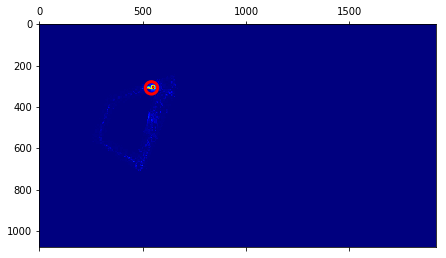

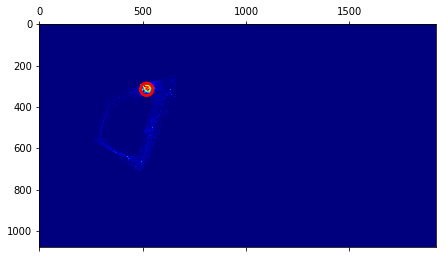

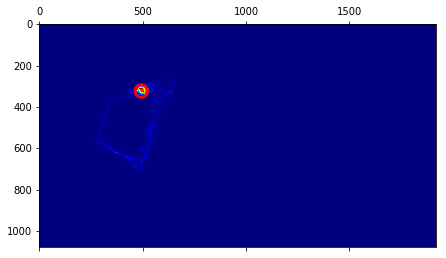

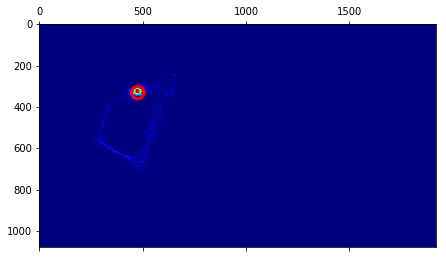

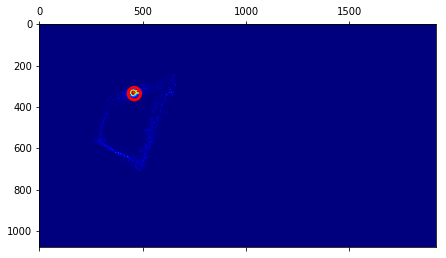

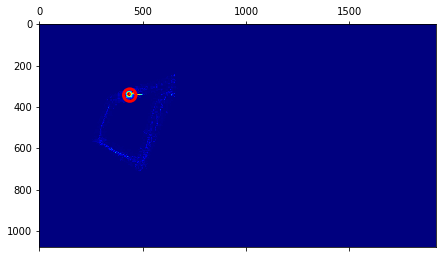

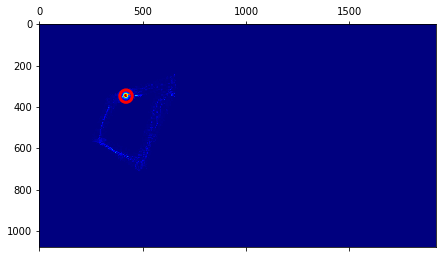

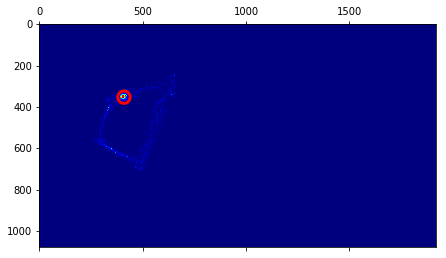

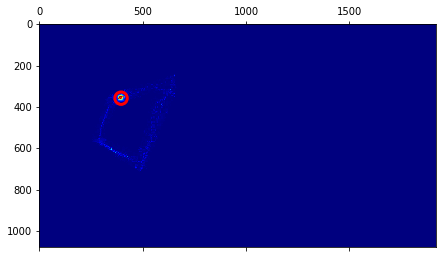

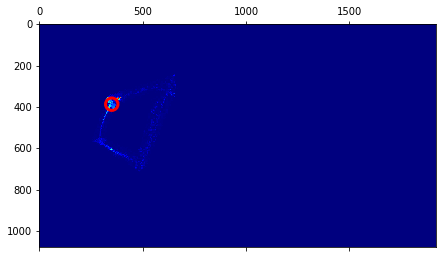

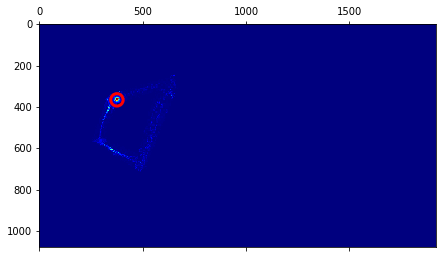

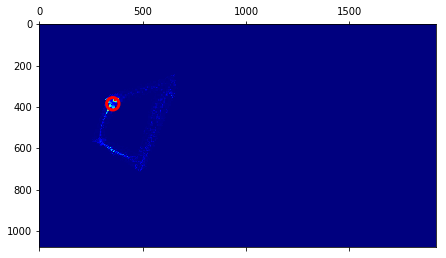

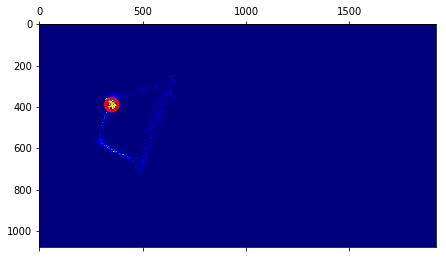

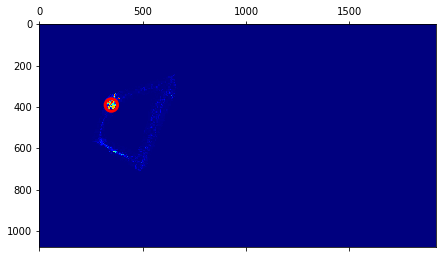

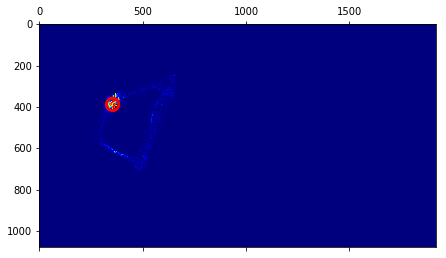

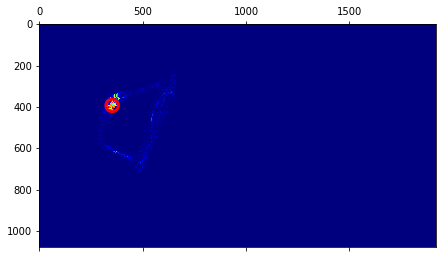

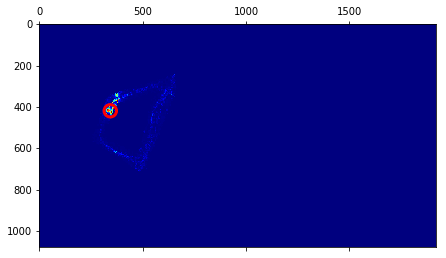

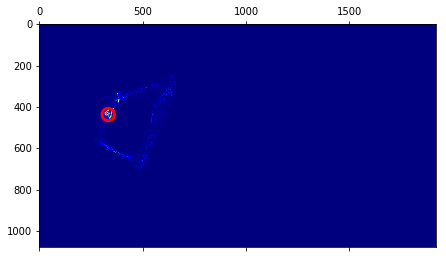

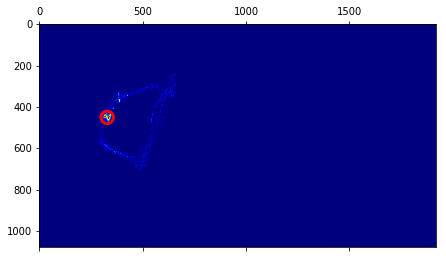

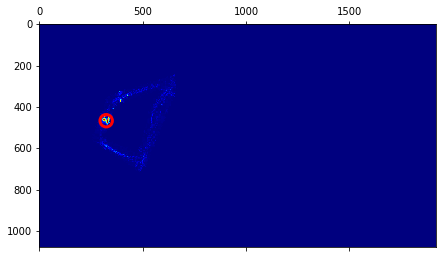

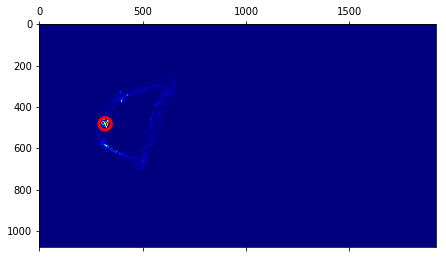

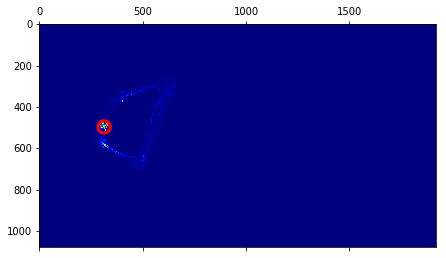

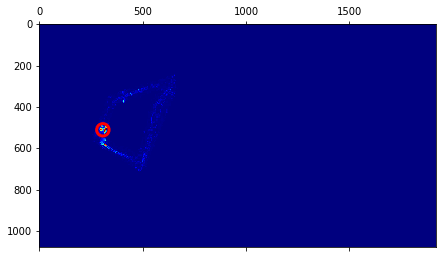

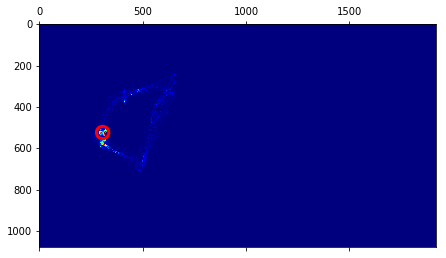

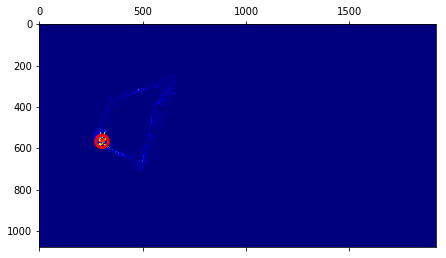

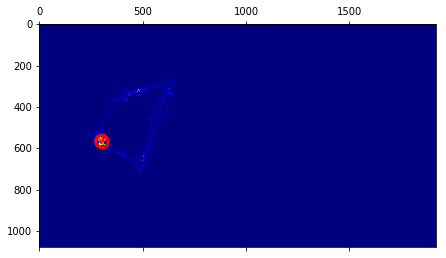

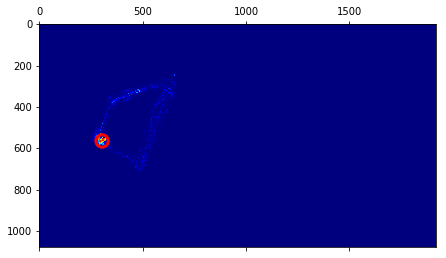

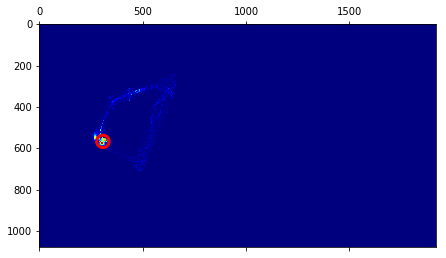

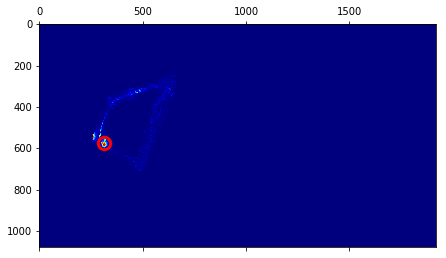

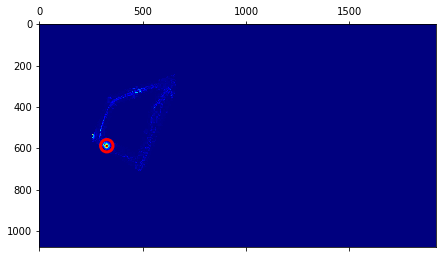

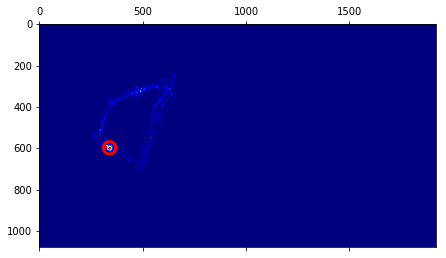

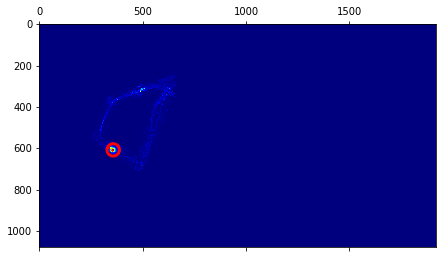

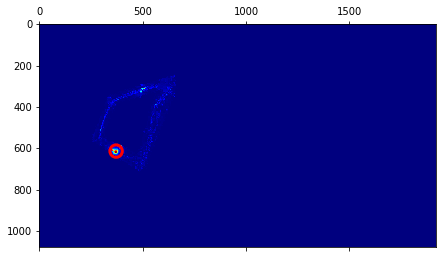

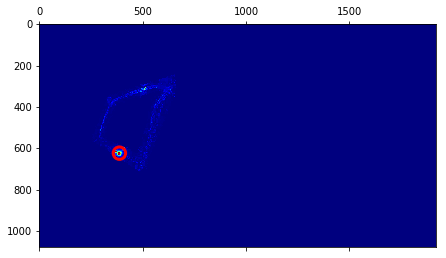

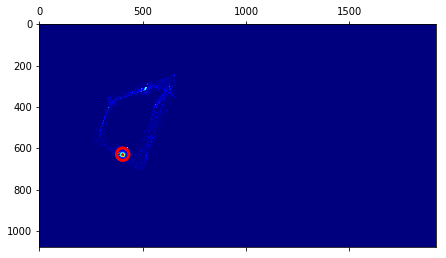

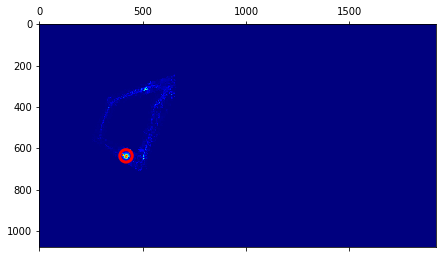

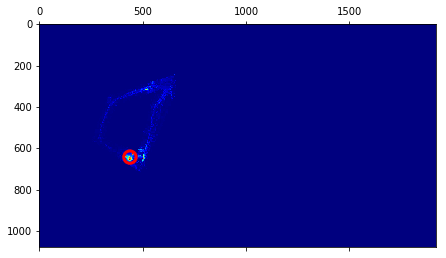

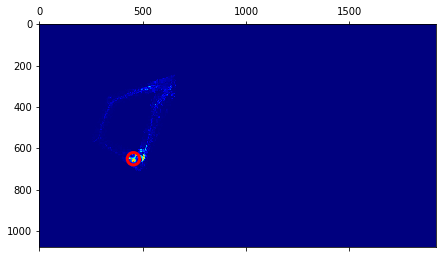

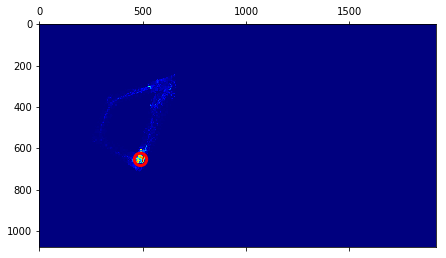

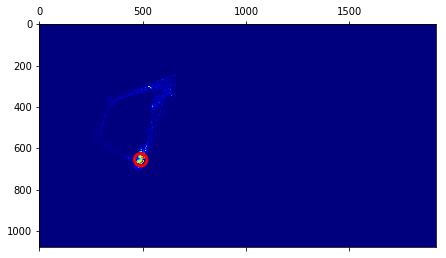

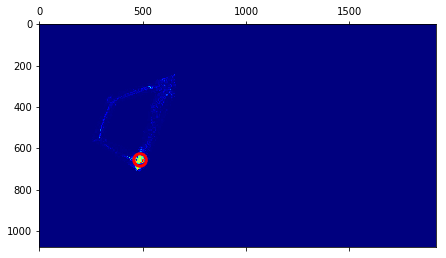

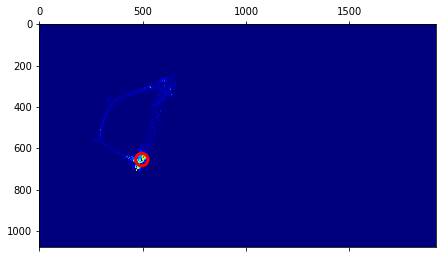

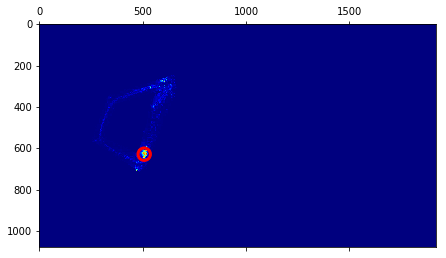

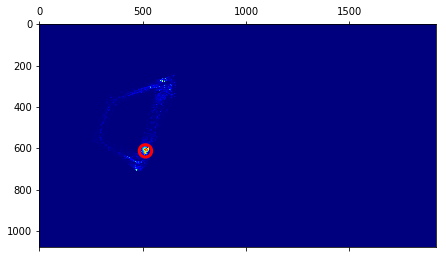

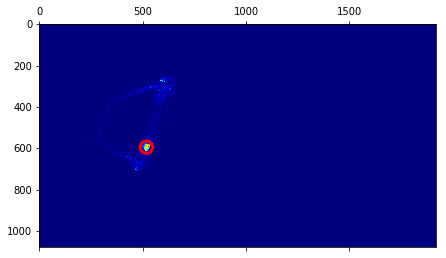

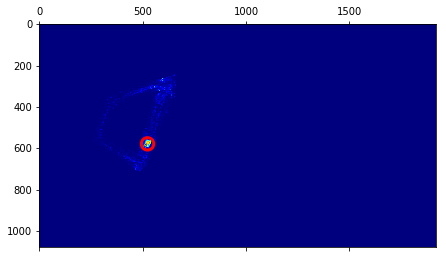

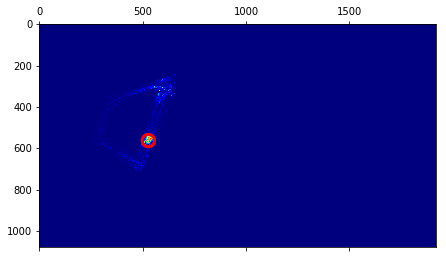

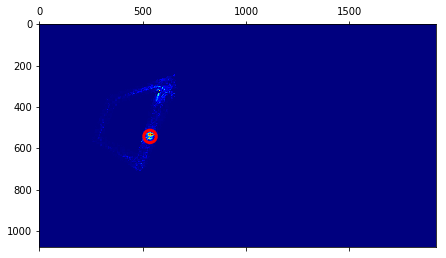

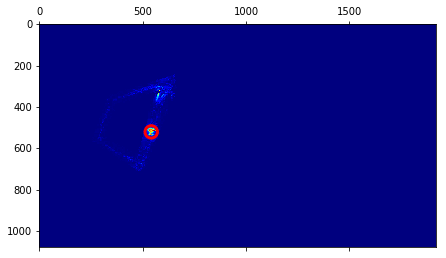

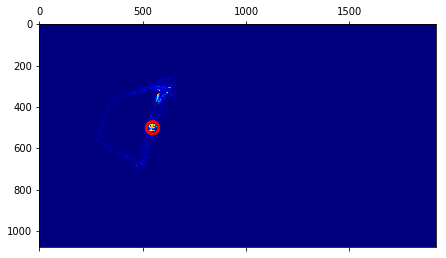

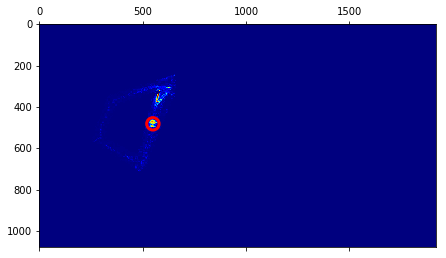

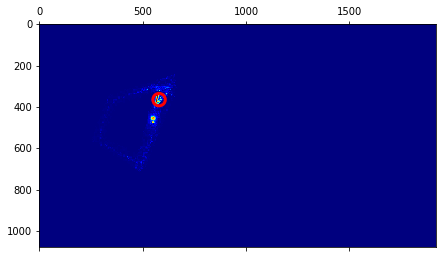

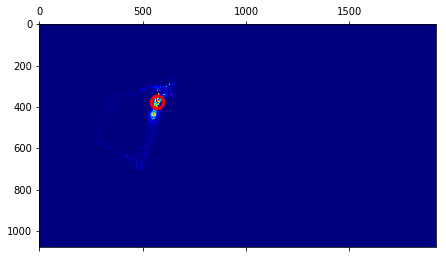

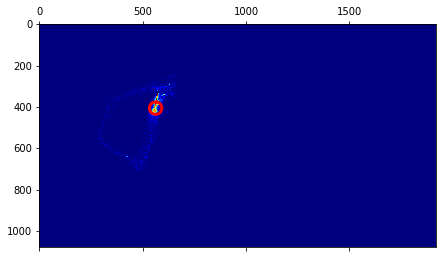

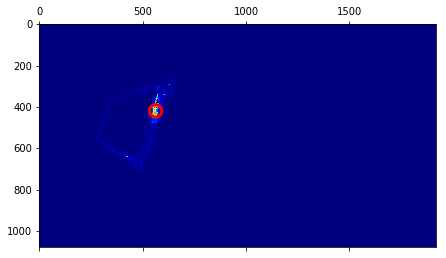

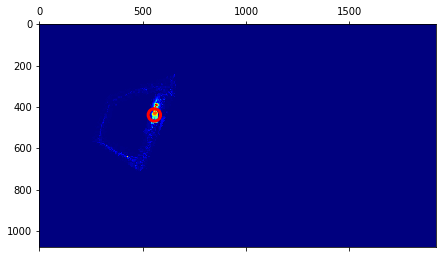

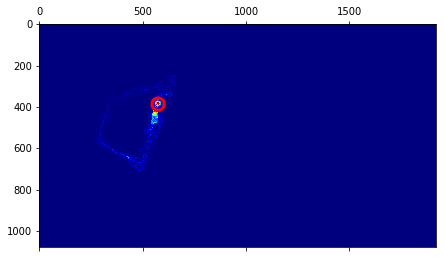

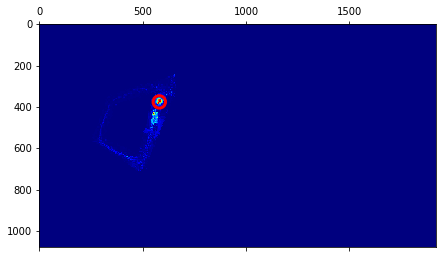

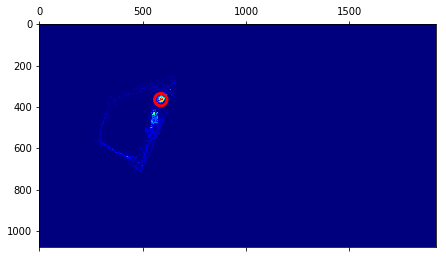

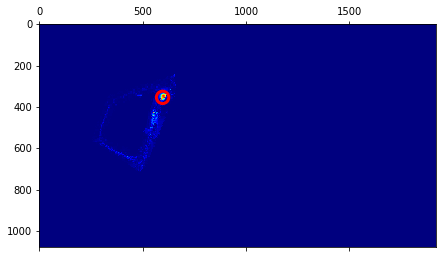

In [94]:
for idx, co in enumerate(pixel_cos): 
    plt.matshow(pix_imgs[idx], cmap='jet')
    ax = plt.gca()
    #ax.set_title("Pixel Nr:", str(idx))
    ax.add_artist(plt.Circle(co[::-1], 30, color='r', fill=False, linewidth=3))

KeyboardInterrupt: 

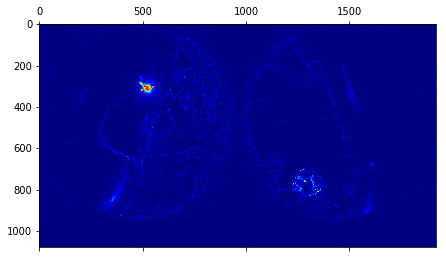

In [26]:
kernel = np.ones([100, 100])

im_idx = 2
max_pix = 0
max_co = [0,0]
for i in range(im0.shape[0] - kernel.shape[0]):
    for j in range(im0.shape[1] - kernel.shape[1]):    
        val = np.sum(data[im_idx, i:i+kernel.shape[0], j:j+kernel.shape[1]]*kernel)
        if val > max_pix:
            max_pix = val
            max_co = [int(i+kernel.shape[0]/2), int(j+kernel.shape[1]/2)]
print(max_pix, max_co)

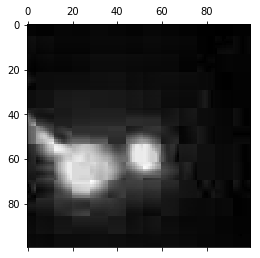

In [51]:
plt.matshow(data[2, 250:350, 500:600], cmap='gray')


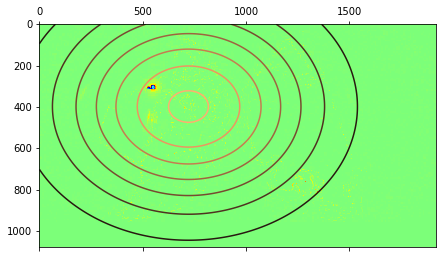

In [39]:
plt.matshow(data[0], cmap='jet')

params = fitgaussian(data[0])
fit = gaussian(*params)

plt.contour(fit(*np.indices(data.shape[1:])), cmap=plt.cm.copper)
ax = plt.gca()
(height, x, y, width_x, width_y) = params


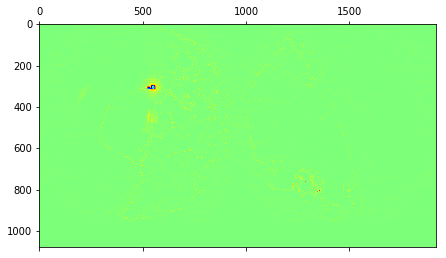

In [32]:
ref_img.shape
plt.matshow(data[0], cmap='jet')

In [35]:
import numpy as np
from numpy import pi, r_
import matplotlib.pyplot as plt
from scipy import optimize

def gaussian(height, center_x, center_y, width_x, width_y):
    """Returns a gaussian function with the given parameters"""
    width_x = float(width_x)
    width_y = float(width_y)
    return lambda x,y: height*np.exp(
                -(((center_x-x)/width_x)**2+((center_y-y)/width_y)**2)/2)

def moments(data):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution by calculating its
    moments """
    total = data.sum()
    X, Y = np.indices(data.shape)
    x = (X*data).sum()/total
    y = (Y*data).sum()/total
    col = data[:, int(y)]
    width_x = np.sqrt(np.abs((np.arange(col.size)-y)**2*col).sum()/col.sum())
    row = data[int(x), :]
    width_y = np.sqrt(np.abs((np.arange(row.size)-x)**2*row).sum()/row.sum())
    height = data.max()
    return height, x, y, width_x, width_y

def fitgaussian(data):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution found by a fit"""
    params = moments(data)
    errorfunction = lambda p: np.ravel(gaussian(*p)(*np.indices(data.shape)) -
                                 data)
    p, success = optimize.leastsq(errorfunction, params)
    return p

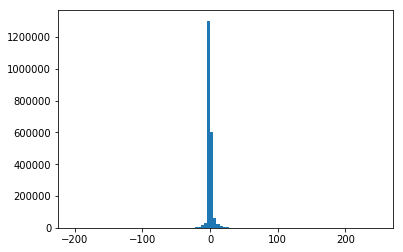

In [61]:
plt.hist((im[:,:,1] - im0).reshape(-1), bins=100);

In [106]:
pix_imgs = data[::3]
len(pix_imgs)

60